In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


<a id="Libraries"></a>
# Libraries

In [2]:
#Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('display.max_columns', 100)
pd.set_option('display.expand_frame_repr', False)
#pd.set_option('display.max_rows', 500)
#pd.set_option('display.max_columns', 500)
#pd.set_option('display.width', 1000)


from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance
from xgboost import cv
#from sklearn.ensemble.gradient_boosting import GradientBoostingClassifier
from sklearn.metrics import mean_squared_error,roc_auc_score,precision_score
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
pd.set_option('max_rows',None)

<a id="Helper-Functions"></a>
# Helper Functions

In [3]:
#Helper functions

#Create function for missing data analysis
def draw_missing_data_table(df):
  total=df.isnull().sum().sort_values(ascending=False)
  percent=(df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
  missing_data=pd.concat([total,percent],axis=1,keys=['Total','Percent'])
  return missing_data

In [4]:
#Plot learning curve
def plot_learning_curve(estimator, title, x,y,ylim=None, cv=None,n_jobs=1,train_sizes=np.linspace(.1,1,5)):
  plt.figure()
  plt.title(title)
  if ylim is not None:
    plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(estimator,x,y,cv=cv,n_jobs=n_jobs,train_sizes=train_sizes)
    train_scores_mean=np.mean(train_scores,axis=1)
    train_scores_std=np.std(train_scores,axis=1)
    test_scores_mean=np.mean(test_scores,axis=1)
    test_scores_std=np.std(test_scores,axis=1)
    plt.grid()
    plt.fill_between(train_sizes,train_scores_mean-train_scores_std,train_scores_mean+train_scores_std,alpha=0.1,color='g')
    plt.plot(train_sizes,train_scores_mean,'o-',color='r',label="Training score")
    plt.plot(train_sizes,test_scores_mean,'o-',color='g',label='Validation score')
    plt.legend(loc="best")
    return plt

In [5]:
#plot validation curve
def plot_validation_curve(estimator, title,x,y,param_name,param_range,ylim=None,cv=None,n_jobs=1,train_sizes=np.linspace(.1,1,5)):
  train_scores,test_scores=validation_curve(estimator,x,y,param_name,param_range,cv)
  train_mean=np.mean(train_scores,axis=1)
  train_std=np.std(train_scores,axis=1)
  test_mean=np.mean(test_scores,axis=1)
  test_std=np.std(test_scores,axis=1)
  plt.plot(param_range,train_mean,color='r',marker='o',markersize=5,label='Training Score')
  plt.fill_between(param_range,train_mean+train_std,train_mean-train_std,alpha=0.15,color='r')
  plt.plot(param_range,test_mean,color='g',linstyle='--',marker='s',markersize=5,label='Validation score')
  plt.fill_between(param_range, test_mean+test_std, test_mean-test_std,alpha=0.15,color='g')
  plt.grid()
  plt.xscale('log')
  plt.legend(loc='best')
  plt.xlabel('Parameter')
  plt.ylabel('Score')
  plt.ylim(ylim)

In [6]:
#get path from training and test data
curr_path = os.getcwd()
dataset_src=os.path.join(curr_path,'spaceship titanic')
train_path=os.path.join(dataset_src,'train.csv')
test_path=os.path.join(dataset_src,'test.csv')

<a id="Load-Dataset"></a>
# Load Dataset

In [7]:
#import data
#train_df=pd.read_csv(train_path)
test_df=pd.read_csv('/kaggle/input/spaceship-titanic/test.csv')
df=pd.read_csv('/kaggle/input/spaceship-titanic/train.csv')
df_raw=df.copy()
train_df=df.copy()
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


Adverserial Validation
Adversarial Validation is a very clever and very simple way to let us know if our test data and our training data are similar; we combine our train and test data, labeling them with say a 0 for the training data and a 1 for the test data, mix them up, then see if we are able to correctly re-identify them using a binary classifier.
ref:https://www.kaggle.com/code/craigmthomas/play-s3e4-adversarial-validation/notebook
https://www.kaggle.com/code/carlmcbrideellis/what-is-adversarial-validation

When we have a ROC of 0.5 then your local data is representative of the test data, thus your local CV score should now be representative of the Public LB score.

In [8]:
train=train_df.drop(["PassengerId",'Transported'],axis=1)
test=test_df.drop('PassengerId',axis=1)
train['test']=0
test['test']=1
# select only the numerical features
train1=train.select_dtypes(include=['number']).copy()
test1=test.select_dtypes(include=['number']).copy()
combined=train1.copy()
combined=pd.concat([combined,test1]).reset_index(drop=True)
print(combined.shape)
train.info()

(12970, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8492 non-null   object 
 1   CryoSleep     8476 non-null   object 
 2   Cabin         8494 non-null   object 
 3   Destination   8511 non-null   object 
 4   Age           8514 non-null   float64
 5   VIP           8490 non-null   object 
 6   RoomService   8512 non-null   float64
 7   FoodCourt     8510 non-null   float64
 8   ShoppingMall  8485 non-null   float64
 9   Spa           8510 non-null   float64
 10  VRDeck        8505 non-null   float64
 11  Name          8493 non-null   object 
 12  test          8693 non-null   int64  
dtypes: float64(6), int64(1), object(6)
memory usage: 883.0+ KB


In [9]:
import xgboost as xgb
# shuffle
combined_s=combined.sample(frac=1)

#Separate target 
X=combined_s.drop(['test'],axis=1)
y=combined_s['test']
XGBdata=xgb.DMatrix(data=X,label=y)

In [10]:
#define xgb parameters
params={'objective':'binary:logistic',
        'eval_metric':'logloss',
        'learning_rate':0.05,
        'max_depth':5
       }
#perform cross validation with XGBoost
cross_val_results=cv(dtrain=XGBdata,params=params,
                    nfold=5,metrics='auc',
                    num_boost_round=200,early_stopping_rounds=20,
                    as_pandas=True)
#print out the final results
print((cross_val_results['test-auc-mean']).tail(1))

0    0.494663
Name: test-auc-mean, dtype: float64


We have a much better result, indicating that both the train and the test features have the same distributions.

Lets dig deeper

We shall now compare each feature individually. For continuous distributions one uses the Kolmogorov-Smirnov test of goodness of fit, here using the SciPy kstest (For categorical data one should use Pearson's chi-squared test). We shall be calculating the  
p
 -values of the hypothesis that the two distributions are indeed the same.

In [11]:
from scipy import stats
feature_list=test1.columns.values.tolist()
for feature in feature_list:
    statistic,pvalue=stats.kstest(train[feature],test[feature])
    print('KS test value: %.3f' %statistic, ' with a p-value %.2f' %pvalue,'for the feature',feature)

KS test value: 0.018  with a p-value 0.29 for the feature Age
KS test value: 0.007  with a p-value 1.00 for the feature RoomService
KS test value: 0.008  with a p-value 0.99 for the feature FoodCourt
KS test value: 0.008  with a p-value 0.99 for the feature ShoppingMall
KS test value: 0.007  with a p-value 1.00 for the feature Spa
KS test value: 0.016  with a p-value 0.44 for the feature VRDeck
KS test value: 1.000  with a p-value 1.00 for the feature test


If we see extremely large values for the KS test in conjunction with very small  
p
 -values for the features , these are precisely the features that have completely different distributions between the training and the test datasets. Here we dont have any such feature that have different distributions between train and test set.

<a id="EDA"></a>
## EDA

Exploratory Data Analysis Not all features provide necessary information for the model. It is essentil to find out important features for analysis.



In [12]:
# Check for missing values
train_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [13]:
# Define the function that creates missing value heatmap
def plot_missing_data(dataset, title):
  fig,ax=plt.subplots(figsize=(5,5))
  plt.title(title)
  sns.heatmap(dataset,cbar=False)

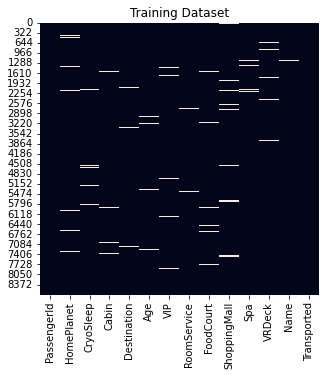

In [14]:
plot_missing_data(df.isnull(),"Training Dataset")

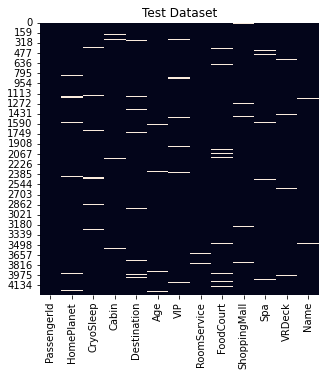

In [15]:
plot_missing_data(test_df.isnull(),"Test Dataset")

In [16]:
# Check number of  missing values in each columns
draw_missing_data_table(train_df)

,Total,Percent
CryoSleep,217,0.024963
ShoppingMall,208,0.023927
VIP,203,0.023352
HomePlanet,201,0.023122
Name,200,0.023007
Cabin,199,0.022892
VRDeck,188,0.021627
FoodCourt,183,0.021051
Spa,183,0.021051
Destination,182,0.020936


In [17]:
# Check features belonging to object category

train_df.select_dtypes(['object']).head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,False,Maham Ofracculy
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,False,Juanna Vines
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,True,Altark Susent
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,False,Solam Susent
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,False,Willy Santantines


In [18]:
test_df.select_dtypes(['object']).head()
#test_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,False,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,False,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,False,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,False,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,False,Brence Harperez


In [19]:
# Impute missing values for Homeplanet
def filling_HomePlanet(df):
  mode=df['HomePlanet'].value_counts().index[0]
  df['HomePlanet']=df['HomePlanet'].fillna(mode)
  return df

In [20]:
# define function for imputing missing values of cryosleep
#if passenger had elected to put himself into suspended animation rarely it would have a missing value, we are going to consider the option of replacing missing values with False in this case.
def filling_CryoSleep(df):
  df['CryoSleep']=df['CryoSleep'].fillna(False)
  return df

Cabin. As it is shown in the report this feature is categorical. As it is almost impossible to estimate cabin number for a passenger with given format, we are going to split cabin number into three different features. Those are going to be describing: desk, number and side. Thus, we'll start Feature Engineering here (continued in detail subsequently). Next, we are going to replace missing values for deck type feature with F (most repeated value). Hereafter, we are going to fill side feature with most repeated value into decks of type F. Finally, we are going to fill cabin number with half of the maximum cabin number (as cabins belonging to one deck type could have more survival rate whether they are one of the first/last cabin).¶


In [21]:
#Cabin

def split_Cabin(df):
    df['Deck'] = df['Cabin'].str.split("/", n=2, expand=True)[0]
    df['Number'] = df['Cabin'].str.split("/", n=2, expand=True)[1]
    df['Side'] = df['Cabin'].str.split("/", n=2, expand=True)[2]
    df.pop('Cabin')
    return df

def filling_cabin(df):
  df['Deck']=df['Deck'].fillna('F')
  mode=df[df.Deck=='F']['Side'].value_counts().index[0]
  df['Side']=mode
  df['Number']=df['Number'].astype(float)
  df['Number']=df['Number'].fillna(1976/2)
  return df

In [22]:
# Destination. planet the passenger will be debarking to
# We will impute missing values with most repeated value

def filling_destination(df):
  mode=df['Destination'].value_counts().index[0]
  df['Destination']=df['Destination'].fillna(mode)
  return df

In [23]:
#VIP- weather the passenger has paid for special VIP service during the voyage
# VIP service deal has not been taken into data collection so replave missing values with faluse

def filling_vip(df):
  df['VIP']=df['VIP'].fillna(False)
  return df

In [24]:
#Name the first and last name of the passenger
# Replace missing values with none as name must be unique and we can not guess it

def filling_name(df):
  df['Name']=df['Name'].fillna('None')
  return df

In [25]:
# Define a function to call all categorical feature missing value imputation functions as defined above

def filling_categorical(df):
  df = filling_HomePlanet(df)
  df = filling_CryoSleep(df)
  df = split_Cabin(df)
  df = filling_cabin(df)
  df = filling_destination(df)
  df = filling_vip(df)
  df = filling_name(df)
  return df

In [26]:
# Check continuous features
train_df.select_dtypes(['float64']).head()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,39.0,0.0,0.0,0.0,0.0,0.0
1,24.0,109.0,9.0,25.0,549.0,44.0
2,58.0,43.0,3576.0,0.0,6715.0,49.0
3,33.0,0.0,1283.0,371.0,3329.0,193.0
4,16.0,303.0,70.0,151.0,565.0,2.0


In [27]:
test_df.select_dtypes(['float64']).head()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,27.0,0.0,0.0,0.0,0.0,0.0
1,19.0,0.0,9.0,0.0,2823.0,0.0
2,31.0,0.0,0.0,0.0,0.0,0.0
3,38.0,0.0,6652.0,0.0,181.0,585.0
4,20.0,10.0,0.0,635.0,0.0,0.0


<AxesSubplot:>

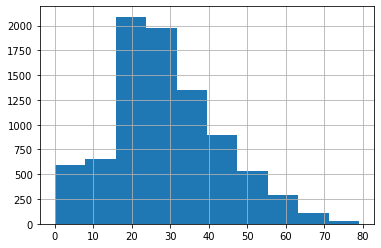

In [28]:
train_df['Age'].hist(bins=10)

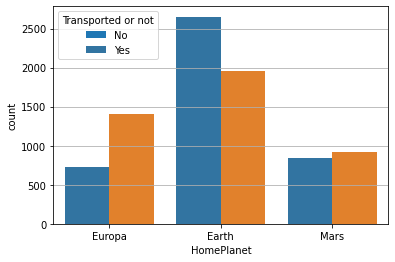

In [29]:
# Cross tab frequency table
#train.groupby(['Fare', 'Survived'])['Fare'].count().unstack()
#filt=train_df.loc[[train_df['Age'] <10],"Age"]
train_df.groupby(['HomePlanet','Transported'])['Transported'].count().hist()
# Draw barplot with cross tab freq values.
ax=sns.countplot(data=train_df,x='HomePlanet',hue='Transported')
#ax.bar_label(ax.containers[0])
#ax.bar_label(ax.containers[1])
plt.legend(title='Transported or not',loc='upper left',labels=['No','Yes'])

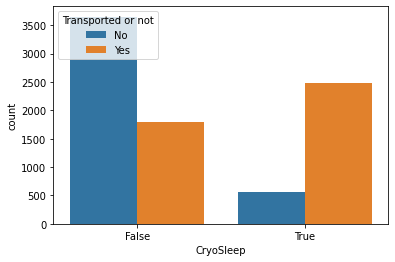

In [30]:
# Draw barplot with cross tab freq values. for biosleep
ax=sns.countplot(data=train_df,x='CryoSleep',hue='Transported')
#plt.bar_label(ax.containers[0])
#plt.bar_label(ax.containers[1])
plt.legend(title='Transported or not',loc='upper left',labels=['No','Yes'])

In [31]:
# Impute age with median

def filling_age(df):
  median = df['Age'].describe()[5]
  df['Age']=df['Age'].fillna(median)
  return df

In [32]:
# Impute all other luxury features
def filling_luxury_features(df):
  luxury_features=['RoomService', 'FoodCourt', 'ShoppingMall','Spa','VRDeck']
  df[luxury_features]=df[luxury_features].fillna(0)
  return df

In [33]:
# Impute all continuous features

def filling_numerical(df):
  df = filling_age(df)
  df = filling_luxury_features(df)
  return df

In [34]:
# Finallly create a function that calls both categorical and continuous function

def filling_missing(df):
  df = filling_categorical(df)
  df = filling_numerical(df)
  return df

# Call function on train data
train_df = filling_missing(train_df)
test_df= filling_missing(test_df)

In [35]:
draw_missing_data_table(test_df)

,Total,Percent
PassengerId,0,0.0
HomePlanet,0,0.0
CryoSleep,0,0.0
Destination,0,0.0
Age,0,0.0
VIP,0,0.0
RoomService,0,0.0
FoodCourt,0,0.0
ShoppingMall,0,0.0
Spa,0,0.0


In [36]:
# Convert all float values to integer for train data
train_df.RoomService=train_df.RoomService.astype(int)
train_df.Age=train_df.Age.astype(int)
train_df.FoodCourt=train_df.FoodCourt.astype(int)
train_df.ShoppigMall=train_df.ShoppingMall.astype(int)
train_df.Spa=train_df.Spa.astype(int)
train_df.VRDeck=train_df.VRDeck.astype(int)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:5: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  """


In [37]:
# Convert all float values to integer for test data
test_df.RoomService=test_df.RoomService.astype(int)
test_df.Age=test_df.Age.astype(int)
test_df.FoodCourt=test_df.FoodCourt.astype(int)
test_df.ShoppigMall=test_df.ShoppingMall.astype(int)
test_df.Spa=test_df.Spa.astype(int)
test_df.VRDeck=test_df.VRDeck.astype(int)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:5: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  """


In [38]:
# Feature engineering
# Base model

def score_dataset(x,y,model=XGBClassifier(label_encoder=False)):
    # Label encoding is good for XGBoost and RandomForest, but one-hot
    # would be better for models like Lasso or Ridge. The `cat.codes`
    # attribute holds the category levels.
    for colname in x.select_dtypes(["object","bool"]).columns:
        x[colname] = LabelEncoder().fit_transform(x[colname])
    y['Transported'] = LabelEncoder().fit_transform(y['Transported'])
    # Metric for Titanic SpaceShipt competition is MAE (Mean Absolute Error)
    score_xgb = cross_val_score(
        model, x, y, cv=5, scoring="accuracy", n_jobs=-1
    )
    
    score = score_xgb.mean()
    return score

x = train_df[train_df.Transported.isnull() == False].copy()
y = pd.DataFrame(x.pop('Transported'))
baseline_score = score_dataset(x, y)
print(f"Baseline score: {baseline_score:.5f} Accuracy")

Baseline score: 0.63489 Accuracy


In [39]:
# Modify Age feature and create new feature
train_df.Age=pd.qcut(train_df['Age'],10)
test_df.Age=pd.qcut(test_df['Age'],10)
test_df.head().style.set_properties(subset=['Age'], **{'background-color':'lightseagreen'})

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Deck,Number,Side
0,0013_01,Earth,True,TRAPPIST-1e,"(26.0, 29.0]",False,0,0,0.000000,0,0,Nelly Carsoning,G,3.000000,P
1,0018_01,Earth,False,TRAPPIST-1e,"(18.0, 21.0]",False,0,9,0.000000,2823,0,Lerome Peckers,F,4.000000,P
2,0019_01,Europa,True,55 Cancri e,"(29.0, 34.0]",False,0,0,0.000000,0,0,Sabih Unhearfus,C,0.000000,P
3,0021_01,Europa,False,TRAPPIST-1e,"(34.0, 40.0]",False,0,6652,0.000000,181,585,Meratz Caltilter,C,1.000000,P
4,0023_01,Earth,False,TRAPPIST-1e,"(18.0, 21.0]",False,10,0,635.000000,0,0,Brence Harperez,F,5.000000,P


In [40]:
# Family features

train_df[['Name','PassengerId']].head().style.set_properties(subset=['PassengerId'],**{'background-color':'lightgreen'})

,Name,PassengerId
0,Maham Ofracculy,0001_01
1,Juanna Vines,0002_01
2,Altark Susent,0003_01
3,Solam Susent,0003_02
4,Willy Santantines,0004_01


In [41]:
# Add new feature for family size. Using last name to find out how manyfamily memebrs are there in FamilySize

train_df['FamilyId'] = train_df['PassengerId'].str.split("_", n=2, expand=True)[0]
train_df['Family Name'] = train_df['Name'].str.split(' ', n=2, expand=True)[1]
train_df = train_df.set_index(['FamilyId','Family Name'])
train_df['Family Size'] = 1

for i in range(train_df.shape[0]):
    fam_size = train_df.loc[train_df.index[i],:].shape[0]
    train_df.loc[train_df.index[i],'Family Size'] = fam_size

train_df=train_df.reset_index()
train_df[['FamilyId','PassengerId','Family Name','Name','Family Size']].head().style.set_properties(subset=['FamilyId','Family Name','Family Size'], **{'background-color':'lightseagreen'})

/opt/conda/lib/python3.7/site-packages/pandas/core/indexing.py:925: PerformanceWarning: indexing past lexsort depth may impact performance.
  return self._getitem_tuple(key)
/opt/conda/lib/python3.7/site-packages/IPython/core/async_helpers.py:78: PerformanceWarning: indexing past lexsort depth may impact performance.
  coro.send(None)


,FamilyId,PassengerId,Family Name,Name,Family Size
0,0001,0001_01,Ofracculy,Maham Ofracculy,1
1,0002,0002_01,Vines,Juanna Vines,1
2,0003,0003_01,Susent,Altark Susent,2
3,0003,0003_02,Susent,Solam Susent,2
4,0004,0004_01,Santantines,Willy Santantines,1


In [42]:
# Do same for test data
test_df['FamilyId'] = test_df['PassengerId'].str.split("_", n=2, expand=True)[0]
test_df['Family Name'] = test_df['Name'].str.split(' ', n=2, expand=True)[1]
test_df = test_df.set_index(['FamilyId','Family Name'])
test_df['Family Size'] = 1

for i in range(test_df.shape[0]):
    fam_size = test_df.loc[test_df.index[i],:].shape[0]
    test_df.loc[test_df.index[i],'Family Size'] = fam_size

test_df=test_df.reset_index()
test_df[['FamilyId','PassengerId','Family Name','Name','Family Size']].head().style.set_properties(subset=['FamilyId','Family Name','Family Size'], **{'background-color':'lightseagreen'})

,FamilyId,PassengerId,Family Name,Name,Family Size
0,0013,0013_01,Carsoning,Nelly Carsoning,1
1,0018,0018_01,Peckers,Lerome Peckers,1
2,0019,0019_01,Unhearfus,Sabih Unhearfus,1
3,0021,0021_01,Caltilter,Meratz Caltilter,1
4,0023,0023_01,Harperez,Brence Harperez,1


In [43]:
#Boolean features encoding
boolean_col = train_df.select_dtypes(['bool']).columns
for i in range(len(boolean_col)):
  train_df[boolean_col[i]].replace([False,True],[0,1],inplace=True)

train_df['Transported'].replace([False,True],[0,1],inplace=True)
boolean_col = test_df.select_dtypes(['bool']).columns
for i in range(len(boolean_col)):
  test_df[boolean_col[i]].replace([False,True],[0,1],inplace=True)

In [44]:
test_df.head()

,FamilyId,Family Name,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Deck,Number,Side,Family Size
0,0013,Carsoning,0013_01,Earth,1,TRAPPIST-1e,"(26.0, 29.0]",0,0,0,0.0,0,0,Nelly Carsoning,G,3.0,P,1
1,0018,Peckers,0018_01,Earth,0,TRAPPIST-1e,"(18.0, 21.0]",0,0,9,0.0,2823,0,Lerome Peckers,F,4.0,P,1
2,0019,Unhearfus,0019_01,Europa,1,55 Cancri e,"(29.0, 34.0]",0,0,0,0.0,0,0,Sabih Unhearfus,C,0.0,P,1
3,0021,Caltilter,0021_01,Europa,0,TRAPPIST-1e,"(34.0, 40.0]",0,0,6652,0.0,181,585,Meratz Caltilter,C,1.0,P,1
4,0023,Harperez,0023_01,Earth,0,TRAPPIST-1e,"(18.0, 21.0]",0,10,0,635.0,0,0,Brence Harperez,F,5.0,P,1


In [45]:
# Categorical features encoding

for colname in train_df.drop('PassengerId',axis=1).select_dtypes(['object','category']).columns:
  train_df[colname]=LabelEncoder().fit_transform(train_df[colname])

In [46]:
train_df.head()

,FamilyId,Family Name,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Deck,Number,Side,Family Size
0,0,1431,0001_01,1,0,2,7,0,0,0,0.0,0,0,5252,0,1,0.0,0,1
1,1,2109,0002_01,0,0,2,3,0,109,9,25.0,549,44,4502,1,5,0.0,0,1
2,2,1990,0003_01,1,0,2,9,1,43,3576,0.0,6715,49,457,0,0,0.0,0,2
3,2,1990,0003_02,1,0,2,6,0,0,1283,371.0,3329,193,7150,0,0,0.0,0,2
4,3,1778,0004_01,0,0,2,1,0,303,70,151.0,565,2,8320,1,5,1.0,0,1


In [47]:
# Do for test data also

for colname in test_df.drop('PassengerId',axis=1).select_dtypes(['object','category']).columns:
  test_df[colname]=LabelEncoder().fit_transform(test_df[colname])

In [48]:
test_df.tail()

,FamilyId,Family Name,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Deck,Number,Side,Family Size
4272,3058,1209,9266_02,0,1,2,6,0,0,0,0.0,0,0,2105,6,1496.0,0,2
4273,3059,1401,9269_01,0,0,2,8,0,0,847,17.0,10,144,2654,5,988.0,0,1
4274,3060,1241,9271_01,2,1,0,4,0,0,0,0.0,0,0,2085,3,296.0,0,1
4275,3061,362,9273_01,1,0,2,4,0,0,2680,0.0,0,523,2327,3,297.0,0,1
4276,3062,948,9277_01,0,1,1,8,0,0,0,0.0,0,0,2439,6,1498.0,0,1


In [49]:
# Modelling
x=train_df.drop(columns=['Transported'])
y=train_df["Transported"]
x_train,x_test, y_train, y_test=train_test_split(x,y,test_size=0.1)

for colname in x_train.select_dtypes(['object','bool']).columns:
  x_train[colname]=LabelEncoder().fit_transform(x_train[colname])

for colname in x_test.select_dtypes(['object','bool']).columns:
  x_test[colname]=LabelEncoder().fit_transform(x_test[colname])

In [50]:
x_train.head()

,FamilyId,Family Name,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Deck,Number,Side,Family Size
8551,6114,485,7695,2,1,2,8,0,0,0,0.0,0,0,1213,5,1765.0,0,1
4570,3271,1255,4151,0,0,1,0,0,0,611,0.0,0,0,615,5,990.0,0,1
3549,2553,730,3224,0,0,2,1,0,14,651,11.0,17,0,7167,5,717.0,0,1
945,672,1979,849,0,1,2,0,0,0,0,0.0,0,0,7249,4,74.0,0,3
5414,3891,1462,4903,1,1,0,2,0,0,0,0.0,0,0,1127,1,195.0,0,3


PassengerID is not going to be useful. Name and Family Name are redundant features as we already have FamilyId,FamilyName and Family Size features. So we should drop them.

<a id="MODELLING"></a>
# MODELLING

<a id="Random forest + Grid search"></a>
#### Random forest + Grid search


In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [52]:
# train model with default parameters
model=RandomForestClassifier(random_state=0)
model.fit(x_train,y_train)

RandomForestClassifier(random_state=0)

In [53]:
#predict using default model parameters
y_pred=model.predict(x_test)
print(accuracy_score(y_test,y_pred))

0.7908045977011494


<a id="Define Hyperparameters Space"></a>
#### Define Hyperparameters Space

Before performing Grid Search, we have to define the hyperparameter space in a dictionary of list format, where the keys refer to the name of the hyperparameters and the lists consist of all the values we want to test for each hyperparameter. Let’s say we define the hyperparameter space for RandomForestClassifier as follows:

In [54]:
hp_space={
    "n_estimators":[25,50,100,150,200],
    "criterion":["gini","entropy"],
    "max_depth": [3,5,10,15,20,None],
    "class_weight":["balanced","balanced_subsample"],
    "min_samples_split":[0.01,0.1,0.25,0.5,0.75,1.0],
}

Once we have defined the hyperparameter space, we can apply the GridSearchCV class to the train data, use the best set of hyperparameters to train a new model on the full train data, and then evaluate that final trained model on the test data.

In [55]:
from sklearn.model_selection import GridSearchCV

<a id="Cross Validation"></a>
#### Cross Validation 

cv=how many folds of cross-validation you want to perform.
n_jobs=-1 means use all parallel processing power(exhaustive cpu use). how many jobs you want to run in parallel.
refit=True This Boolean parameter is responsible for deciding whether at the end of the hyperparameter tuning process we want to refit our model on the full train set using the best set of hyperparameters or not. 

In [56]:
clf=GridSearchCV(model,hp_space,scoring='accuracy',cv=5,n_jobs=-1,refit=True)

In [57]:
clf.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=0), n_jobs=-1,
             param_grid={'class_weight': ['balanced', 'balanced_subsample'],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, 15, 20, None],
                         'min_samples_split': [0.01, 0.1, 0.25, 0.5, 0.75, 1.0],
                         'n_estimators': [25, 50, 100, 150, 200]},
             scoring='accuracy')

In [58]:
#Print the best set of hyperparameters:
print(clf.best_params_,clf.best_score_)

{'class_weight': 'balanced_subsample', 'criterion': 'gini', 'max_depth': None, 'min_samples_split': 0.01, 'n_estimators': 150} 0.7963686132877933


In [59]:
print(clf.score(x_test,y_test))

0.7942528735632184


<a id="PIPELINE"></a>
# PIPELINE

we can create a pipeline for numeric_preprocessor that consists of a chain of missing value imputation and normalization modules. The following code shows how we can create such a pipeline. The SimpleImputer class is the missing value imputation transformer from sklearn that can help us to perform mean, median, mode, or constant imputation strategies if there are any missing values:

In [60]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
numeric_preprocessor=Pipeline(steps=[("missing_value_imputation",SimpleImputer(strategy='mean')),("normalization",StandardScaler())])
pipe = Pipeline(

    steps=[("preprocessor", numeric_preprocessor),

           ("model", RandomForestClassifier(random_state=0))])

<a id="RANDOM SEARCH"></a>
# RANDOM SEARCH

Random Search is very similar to implementing Grid Search. The main difference is that we have to provide the number of trials or iterations since Random Search will not try all of the possible combinations in the hyperparameter space. Additionally, we have to provide the accompanying distribution for each of the hyperparameters when defining the search space.

In [61]:
from scipy.stats import randint,truncnorm

hp_space1={
    "model__n_estimators":randint(5,200),
    "model__criterion":["gini","entropy"],
    "model__class_weight":["balanced","balanced_subsample"],
    "model__min_samples_split":truncnorm(a=0,b=0.5,loc=0.005,scale=0.01)
}

In [62]:
from sklearn.model_selection import RandomizedSearchCV
clf=RandomizedSearchCV(pipe,hp_space1,n_iter=200,random_state=0,
                      scoring='accuracy',cv=5,n_jobs=-1,refit=True)

In [63]:
clf.fit(x_train,y_train)


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              Pipeline(steps=[('missing_value_imputation',
                                                               SimpleImputer()),
                                                              ('normalization',
                                                               StandardScaler())])),
                                             ('model',
                                              RandomForestClassifier(random_state=0))]),
                   n_iter=200, n_jobs=-1,
                   param_distributions={'model__class_weight': ['balanced',
                                                                'balanced_subsample'],
                                        'model__criterion': ['gini', 'entropy'],
                                        'model__min_samples_split': <scipy.stats._distn_infrastructure.rv_frozen object at 0x7f3238189390>,
      

In [64]:
print(clf.best_params_,clf.best_score_)

{'model__class_weight': 'balanced_subsample', 'model__criterion': 'entropy', 'model__min_samples_split': 0.006161847322412901, 'model__n_estimators': 132} 0.7986705669905133


<a id="PREDCITION AND SUBMISSION"></a>
# PREDCITION AND SUBMISSION

In [65]:
#Evaluate the final score on test data
print(clf.score(x_test,y_test))

0.8011494252873563


In [66]:
op=test_df.copy()
#test_df=test_df.drop(columns=["PassengerId","Name","Family Name"])

In [67]:
pred=clf.predict(test_df)
pred

array([1, 0, 1, ..., 1, 1, 1])

In [68]:
op['Survived']=pred

op.head()

,FamilyId,Family Name,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Deck,Number,Side,Family Size,Survived
0,0,275,0013_01,0,1,2,5,0,0,0,0.0,0,0,2912,6,3.0,0,1,1
1,1,1190,0018_01,0,0,2,2,0,0,9,0.0,2823,0,2406,5,4.0,0,1,0
2,2,1604,0019_01,1,1,0,6,0,0,0,0.0,0,0,3377,2,0.0,0,1,1
3,3,262,0021_01,1,0,2,7,0,0,6652,0.0,181,585,2711,2,1.0,0,1,1
4,4,736,0023_01,0,0,2,2,0,10,0,635.0,0,0,668,5,5.0,0,1,0


In [69]:
op.loc[op['Survived'] < 0.5, 'Transported'] = 'False' 
op.loc[op['Survived'] >= 0.5, 'Transported'] = 'True' 
op1=op[["PassengerId","Transported"]]
#op.drop('Survived',axis=1,inplace=True)
op1.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False


In [70]:
op1.to_csv("submission.csv",index=False)